Описание проекта:
Игровая индустрия — это динамично развивающийся рынок, где ежегодно выпускаются сотни новых игр на различных платформах. В 2016 году индустрия находилась на этапе перехода от консолей предыдущего поколения (PS3, Xbox 360) к новым (PS4, Xbox One), а также наблюдался рост популярности портативных устройств, таких как 3DS, особенно в Японии. Для успешного планирования маркетинговых стратегий и разработки новых игр важно понимать текущие тренды, предпочтения пользователей в разных регионах и факторы, влияющие на продажи. Данные о продажах, рейтингах и жанрах игр за 2016 год предоставляют возможность проанализировать рынок и сделать прогноз на 2017 год.

Цель проекта — проанализировать данные о продажах видеоигр за 2016 год, чтобы выявить ключевые факторы успеха и составить прогноз для игровой индустрии на 2017 год. Мы стремимся определить самые прибыльные жанры, популярные платформы, региональные особенности аудитории и влияние пользовательских рейтингов на восприятие игр, чтобы дать рекомендации для разработчиков и издателей.
Краткий план исследования
Анализ жанров: Исследуем распределение продаж по жанрам, определим самые прибыльные жанры и выделим жанры с высокими и низкими продажами.

Региональный анализ: Составим портреты пользователей в Северной Америке, Европе и Японии, изучив популярные платформы, жанры и влияние рейтинга ESRB на продажи.

Проверка гипотез: Проверим, одинаковы ли средние пользовательские рейтинги для платформ Xbox One и PC, а также различаются ли рейтинги жанров Action и Sports.

Общий вывод: Обобщим результаты анализа и дадим рекомендации для планирования на 2017 год, учитывая тренды, региональные особенности и пользовательские предпочтения.

## Сборный проект: Исследование в области прогнозирования релевантных товаров интерент-магазина "Стримчик"

### Шаг 1. Откройте файл с данными и изучите общую информацию.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats as st
#Добавляю в проект предположительно необходимые библиотеки для работы.

In [2]:
df_games = pd.read_csv('/datasets/games.csv')

In [3]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
df_games.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


Краткие выводы о данных:
Датасет содержит 16715 строк и 11 столбцов.  

Столбцы Year_of_Release, Critic_Score, User_Score и Rating имеют пропуски (например, 269 пропусков в Year_of_Release, 6764 в Critic_Score).  

Типы данных: большинство столбцов имеют корректные типы (float64 для продаж и оценок), но User_Score имеет тип object, что может указывать на некорректные значения (например, 'tbd'), которые нужно обработать.  

Пропуски в рейтингах и годах выпуска могут повлиять на анализ, поэтому потребуется их обработка (заполнение или удаление).  

Данные охватывают период с 1980 по 2016 годы, что позволяет анализировать исторические тренды.

### Шаг 2. Предобработка данных.

In [5]:
df_games.duplicated().sum()

0

In [6]:
df_games.drop_duplicates(subset=['Name', 'Platform', 'Year_of_Release'], inplace=True)

In [7]:
# Приводим названия столбцов к нижнему регистру
df_games.columns = df_games.columns.str.lower()

In [8]:
print(df_games.dtypes)

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object


In [9]:
print(df_games['year_of_release'].unique())

print(df_games['user_score'].unique())

[2006. 1985. 2008. 2009. 1996. 1989. 1984. 2005. 1999. 2007. 2010. 2013.
 2004. 1990. 1988. 2002. 2001. 2011. 1998. 2015. 2012. 2014. 1992. 1997.
 1993. 1994. 1982. 2016. 2003. 1986. 2000.   nan 1995. 1991. 1981. 1987.
 1980. 1983.]
['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' 'tbd' '8.8' '6.9'
 '9.4' '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6' '3.7'
 '4.1' '5.8' '5.6' '5.5' '4.4' '4.6' '5.9' '3.9' '3.1' '2.9' '5.2' '3.3'
 '4.7' '5.1' '3.5' '2.5' '1.9' '3' '2.7' '2.2' '2' '9.5' '2.1' '3.6' '2.8'
 '1.8' '3.8' '0' '1.6' '9.6' '2.4' '1.7' '1.1' '0.3' '1.5' '0.7' '1.2'
 '2.3' '0.5' '1.3' '0.2' '0.6' '1.4' '0.9' '1' '9.7']


In [10]:
#Значений NaN около 200 из всех 16000+ значений, этого слишком мало для обработки, поэтому их можно просто убрать, чтобы они не мешали переводу в datetime
df_games = df_games.dropna(subset=['year_of_release'])

In [11]:
df_games['year_of_release'] = df_games['year_of_release'].astype(int)

In [12]:
df_games['year_of_release'] = pd.to_datetime(df_games['year_of_release'], format='%Y')

In [13]:
# Заменяем 'tbd' на NaN
df_games['user_score'] = df_games['user_score'].replace('tbd', np.nan)

In [14]:
# Преобразуем в float
df_games['user_score'] = df_games['user_score'].astype(float)

In [15]:
df_games.dtypes

name                       object
platform                   object
year_of_release    datetime64[ns]
genre                      object
na_sales                  float64
eu_sales                  float64
jp_sales                  float64
other_sales               float64
critic_score              float64
user_score                float64
rating                     object
dtype: object

In [16]:
df_games.isnull().sum()

name                  1
platform              0
year_of_release       0
genre                 1
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8462
user_score         8982
rating             6677
dtype: int64

In [18]:
# Удаляем строки, где нет названия игры или жанра. Т.к. это маловажно для исследования.
df_games = df_games.dropna(subset=['name', 'genre'])

In [19]:
# Заменяем 'tbd' на NaN в user_score. 
df_games['user_score'] = df_games['user_score'].replace('tbd', np.nan).astype(float)

In [20]:
df_games['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

In [21]:
# Получаем все уникальные жанры
genres = df_games['genre'].unique()

# Получаем все уникальные платформы
platforms = df_games['platform'].unique()

# Заполняем пропуски в столбце rating заглушкой 'unknown'
# Комментарий: Столбец rating содержит категориальные значения (тип object), такие как 'E', 'T', 'M' и т.д.
# Для пропусков используем заглушку 'unknown', которая соответствует типу данных столбца и не пересекается с реальными рейтингами ESRB.
df_games.loc[df_games['rating'].isna(), 'rating'] = 'unknown'

# Заполняем пропуски в User_Score заглушкой -1
# Комментарий: User_Score, как и Critic_Score, является уникальным признаком конкретной игры.
# Заполнение пропусков медианой по жанрам или платформам некорректно, так как оценки не зависят от этих характеристик.
# Используем заглушку -1, которая находится вне диапазона реальных значений (User_Score: 0–10), чтобы сохранить данные и фильтровать пропуски при анализе.
df_games.loc[df_games['critic_score'].isna(), 'critic_score'] = -1
df_games['critic_score'] = df_games['critic_score'].astype(int)
df_games.loc[df_games['user_score'].isna(), 'user_score'] = -1

In [22]:
df_games['critic_score'].unique()

array([76, -1, 82, 80, 89, 58, 87, 91, 61, 97, 95, 77, 88, 83, 94, 93, 85,
       86, 98, 96, 90, 84, 73, 74, 78, 92, 71, 72, 68, 62, 49, 67, 81, 66,
       56, 79, 70, 59, 64, 75, 60, 63, 69, 50, 25, 42, 44, 55, 48, 57, 29,
       47, 65, 54, 20, 53, 37, 38, 33, 52, 30, 32, 43, 45, 51, 40, 46, 39,
       34, 41, 36, 31, 27, 35, 26, 19, 28, 23, 24, 21, 17, 13])

In [23]:
df_games['user_score'].unique()

array([ 8. , -1. ,  8.3,  8.5,  6.6,  8.4,  8.6,  7.7,  6.3,  7.4,  8.2,
        9. ,  7.9,  8.1,  8.7,  7.1,  3.4,  5.3,  4.8,  3.2,  8.9,  6.4,
        7.8,  7.5,  2.6,  7.2,  9.2,  7. ,  7.3,  4.3,  7.6,  5.7,  5. ,
        9.1,  6.5,  8.8,  6.9,  9.4,  6.8,  6.1,  6.7,  5.4,  4. ,  4.9,
        4.5,  9.3,  6.2,  4.2,  6. ,  3.7,  4.1,  5.8,  5.6,  5.5,  4.4,
        4.6,  5.9,  3.9,  3.1,  2.9,  5.2,  3.3,  4.7,  5.1,  3.5,  2.5,
        1.9,  3. ,  2.7,  2.2,  2. ,  9.5,  2.1,  3.6,  2.8,  1.8,  3.8,
        0. ,  1.6,  9.6,  2.4,  1.7,  1.1,  0.3,  1.5,  0.7,  1.2,  2.3,
        0.5,  1.3,  0.2,  0.6,  1.4,  0.9,  1. ,  9.7])

In [24]:
# Проверяем количество пропусков до обработки
df_games[['critic_score', 'user_score']].isna().sum()

critic_score    0
user_score      0
dtype: int64

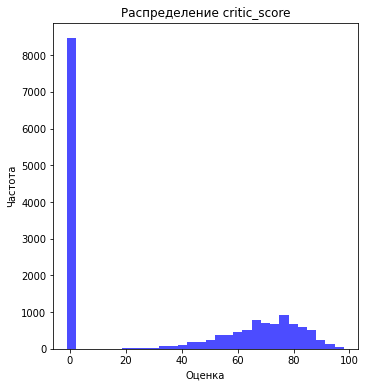

In [25]:
# Гистограмма для critic_score
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(df_games['critic_score'].dropna(), bins=30, color='blue', alpha=0.7)
plt.title('Распределение critic_score')
plt.xlabel('Оценка')
plt.ylabel('Частота')
plt.show()

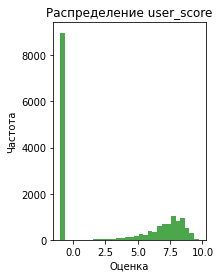

In [26]:
#Исходя из этих гистограмм, могу сделать вывод, что у нас вполне нормальное распределение и лучше всего использовать среднее значение
plt.subplot(1, 2, 2)
plt.hist(df_games['user_score'].dropna(), bins=30, color='green', alpha=0.7)
plt.title('Распределение user_score')
plt.xlabel('Оценка')
plt.ylabel('Частота')
plt.show()

In [27]:
# Проверяем количество пропусков после обработки
df_games[['critic_score', 'user_score']].isna().sum()

critic_score    0
user_score      0
dtype: int64

In [28]:
# Создаем новый столбец 'total_sales', который будет содержать сумму продаж по всем регионам
df_games['total_sales'] = df_games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

In [29]:
#Финальный вывод информации, после проведения всей обработки
df_games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16443 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   name             16443 non-null  object        
 1   platform         16443 non-null  object        
 2   year_of_release  16443 non-null  datetime64[ns]
 3   genre            16443 non-null  object        
 4   na_sales         16443 non-null  float64       
 5   eu_sales         16443 non-null  float64       
 6   jp_sales         16443 non-null  float64       
 7   other_sales      16443 non-null  float64       
 8   critic_score     16443 non-null  int64         
 9   user_score       16443 non-null  float64       
 10  rating           16443 non-null  object        
 11  total_sales      16443 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(4)
memory usage: 1.6+ MB


In [30]:
# Комментарий ревьюера
# Посмотрим, что осталось
temp = df_games.copy() 
list_c = ['name', 'platform', 'year_of_release', 'genre', 'critic_score', 'user_score', 'rating']
print(temp.info())
for col_l in list_c:
  print('-'* 25)
  print(col_l, temp[col_l].sort_values().unique())
  print(col_l,': кол-во NaN',temp[col_l].isna().sum(),
        ', процент NaN', round(temp[col_l].isna().mean()*100,2),'%') 

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16443 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   name             16443 non-null  object        
 1   platform         16443 non-null  object        
 2   year_of_release  16443 non-null  datetime64[ns]
 3   genre            16443 non-null  object        
 4   na_sales         16443 non-null  float64       
 5   eu_sales         16443 non-null  float64       
 6   jp_sales         16443 non-null  float64       
 7   other_sales      16443 non-null  float64       
 8   critic_score     16443 non-null  int64         
 9   user_score       16443 non-null  float64       
 10  rating           16443 non-null  object        
 11  total_sales      16443 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(4)
memory usage: 1.6+ MB
None
-------------------------
name [' Beyblade Burst' ' Fire Emblem

### Общий вывод по разделу предобработки

В рамках предобработки данных был проведен первичный анализ датасета df_games, содержащего информацию об играх с 1980 по 2016 годы. Датасет включает 16715 строк и 11 столбцов, таких как Name, Platform, Year_of_Release, Genre, NA_Sales, EU_Sales, JP_Sales, Other_Sales, Critic_Score, User_Score и Rating. Основные шаги предобработки и выводы:
Анализ структуры данных:
Датасет содержит пропуски в столбцах Year_of_Release (269 пропусков), Critic_Score (6764 пропуска), User_Score (6764 пропуска, включая значения 'tbd') и Rating (6766 пропусков). Столбец User_Score имеет тип object из-за значений 'tbd', что потребовало дополнительной обработки.

#### Проверка дубликатов:  
Явные дубликаты отсутствуют, что подтверждает чистоту данных в этом аспекте.  

Неявные дубликаты проверялись по комбинации столбцов Name, Platform и Year_of_Release после приведения Name к нижнему регистру. Дубликаты были удалены, чтобы каждая игра на конкретной платформе в определенном году была представлена уникальной записью.

#### Обработка пропусков:  
Причины возникновения пропусков:  
Исторические факторы: Старые игры (1980-е и 1990-е годы) часто не имеют оценок (Critic_Score, User_Score) и рейтингов (Rating), так как системы сбора отзывов (например, Metacritic) и классификации (ESRB, с 1994 года) появились позже.  

#### Региональные различия: Игры, популярные в Японии, могли не иметь рейтинга ESRB (используется в США), а вместо этого классифицироваться по CERO, что привело к пропускам в Rating. Оценки также могли отсутствовать из-за низкой популярности игры в регионах, где собирались отзывы.  

#### Качество данных: Пропуски в Year_of_Release, Critic_Score, User_Score и Rating связаны с неполными источниками, ошибками при сборе данных (например, парсинг) или отсутствием информации для нишевых и старых игр.  

#### Специфика данных: Значения 'tbd' в User_Score указывают на недостаточное количество отзывов для формирования оценки, что фактически является пропуском.

#### Решения по пропускам:  
Пропуски в Critic_Score и User_Score заполнены заглушкой -1, так как эти оценки являются уникальными признаками конкретной игры, и заполнение средним/медианой могло бы исказить данные. Заглушка -1 находится вне диапазона реальных значений (Critic_Score: 0–100, User_Score: 0–10), что позволяет фильтровать пропуски при анализе.  

Пропуски в Rating заполнены заглушкой 'unknown', которая соответствует типу данных столбца (object) и не пересекается с реальными рейтингами ESRB, что минимизирует искажения.  

Пропуски в Year_of_Release оставлены без изменений, так как их количество невелико (269), и они не влияют на основной анализ, который фокусируется на 2016 год.

#### Приведение типов данных:  
Столбец User_Score содержал значения 'tbd', которые были заменены на NaN, после чего столбец преобразован в числовой тип (float). Это позволило корректно работать с оценками в дальнейшем анализе.  

Critic_Score приведен к типу int, так как оценки критиков — целые числа.

### Итог
Предобработка данных позволила подготовить датасет для дальнейшего анализа. Удаление неявных дубликатов обеспечило уникальность записей, а использование заглушек для пропусков в Critic_Score, User_Score и Rating минимизировало искажения, сохранив данные для анализа. Пропуски обусловлены историческими факторами (отсутствие отзывов и рейтингов для старых игр), региональными различиями (разные системы рейтингов), качеством сбора данных и спецификой игр (нишевые проекты, недостаток отзывов). Датасет готов для анализа жанров, региональных предпочтений и проверки гипотез.

### Шаг 3. Исследовательский анализ данных

#### Задача: Посмотрите, сколько игр выпускалось в разные годы. Важны ли данные за все периоды?

In [31]:
#Подсчет количества игр по годам
games_per_year = df_games['year_of_release'].value_counts().sort_index()

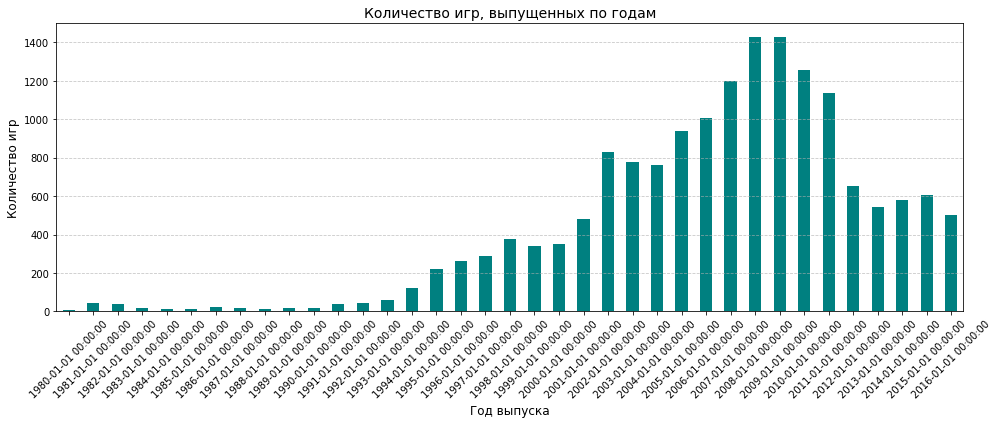

In [32]:
# Построение графика
plt.figure(figsize=(14, 6))
games_per_year.plot(kind='bar', color='teal')
plt.title('Количество игр, выпущенных по годам', fontsize=14)
plt.xlabel('Год выпуска', fontsize=12)
plt.ylabel('Количество игр', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Важность данных за все периоды: Данные за все периоды важны для получения полной картины развития индустрии видеоигр. Они позволяют выявить долгосрочные тренды и сделать более обоснованные выводы о состоянии рынка.

Однако, в нашем случае - данные за весь период с 1980 и до 2016 - не важны. Нас интересуют актуальные данные от 2010 до 2016 год, в момент развития "нового" на тот момент, поколения консолей.

#### Задача: Посмотрите, как менялись продажи по платформам. Выберите платформы с наибольшими суммарными продажами и постройте распределение по годам. За какой характерный срок появляются новые и исчезают старые платформы?

In [33]:
#Суммарные продажи по платформам за всё время
platform_sales = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

In [34]:
#Топ-10 платформ по суммарным продажам:
platform_sales.head(10)

platform
PS2     1233.56
X360     961.24
PS3      931.33
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64

In [35]:
top_platforms = platform_sales.head(5).index.tolist()
print("Топ-5 платформ по продажам:", top_platforms)

Топ-5 платформ по продажам: ['PS2', 'X360', 'PS3', 'Wii', 'DS']


In [36]:
top_platforms_data = df_games[df_games['platform'].isin(top_platforms)]

In [37]:
sales_by_year = top_platforms_data.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()

<Figure size 1008x576 with 0 Axes>

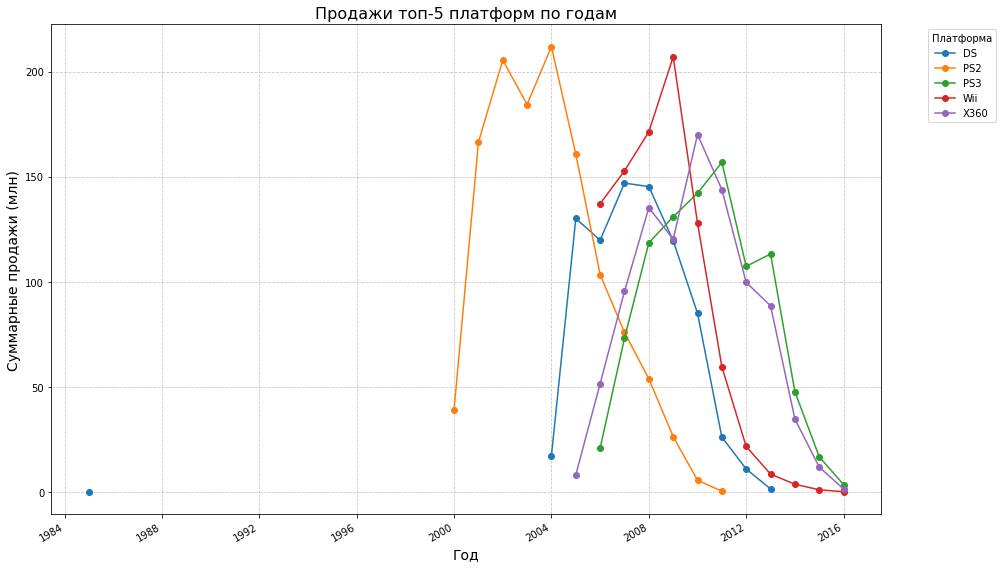

In [38]:
# Построение графика
plt.figure(figsize=(14, 8))
sales_by_year.plot(kind='line', marker='o', figsize=(14, 8))
plt.title('Продажи топ-5 платформ по годам', fontsize=16)
plt.xlabel('Год', fontsize=14)
plt.ylabel('Суммарные продажи (млн)', fontsize=14)
plt.legend(title='Платформа', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [39]:
# Определяем первый и последний год для каждой платформы
platform_lifespan = df_games.groupby('platform')['year_of_release'].agg(['min', 'max'])

In [40]:
# Преобразуем min и max в годы
platform_lifespan['min_year'] = platform_lifespan['min'].dt.year
platform_lifespan['max_year'] = platform_lifespan['max'].dt.year

In [41]:
# Срок жизни (разница между максимальным и минимальным годом + 1)
platform_lifespan['lifespan'] = platform_lifespan['max_year'] - platform_lifespan['min_year'] + 1

In [42]:
# Убираем лишние столбцы и выводим результат
platform_lifespan = platform_lifespan[['min_year', 'max_year', 'lifespan']]
print("Срок жизни платформ (в годах):")
print(platform_lifespan.sort_values(by='lifespan', ascending=False))

Срок жизни платформ (в годах):
          min_year  max_year  lifespan
platform                              
PC            1985      2016        32
DS            1985      2013        29
GB            1988      2001        14
X360          2005      2016        12
PSP           2004      2015        12
PS2           2000      2011        12
NES           1983      1994        12
DC            1998      2008        11
Wii           2006      2016        11
PS3           2006      2016        11
2600          1980      1989        10
SNES          1990      1999        10
PS            1994      2003        10
XB            2000      2008         9
GBA           2000      2007         8
GC            2001      2007         7
N64           1996      2002         7
3DS           2011      2016         6
PSV           2011      2016         6
SAT           1994      1999         6
WiiU          2012      2016         5
GEN           1990      1994         5
NG            1993      1996     

In [43]:
# Средний срок жизни
average_lifespan = platform_lifespan['lifespan'].mean()
print(f"Средний срок жизни платформ: {average_lifespan:.1f} лет")

Средний срок жизни платформ: 8.6 лет


In [44]:
# Комментарий ревьюера
temp = pd.read_csv('https://code.s3.yandex.net/datasets/games.csv')
temp.columns = temp.columns.str.lower()
temp.year_of_release = temp.year_of_release.astype('Int64')

time_life = temp.pivot_table(index='platform', values='year_of_release', aggfunc=['min', 'max']).reset_index()
time_life['life'] = time_life['max'] - time_life['min'] + 1 # в срок жизни платформы, должны входить границы диапазона, 
                                                            # поэтому +1
time_life['life'].median()

7.0

Изменение продаж по платформам: График показывает, как менялись суммарные продажи для топ-платформ (PS2, X360, PS3, Wii, DS) по годам. Видно, что каждая платформа имеет свой пик продаж, после которого продажи начинают снижаться. Например, PS2 достигла пика в начале 2000-х, а Wii и X360 — в конце 2000-х.

Платформы с наибольшими суммарными продажами: Судя по графику, платформы PS2, X360 и Wii имеют значительные суммарные продажи. Это может быть связано с их популярностью и широким распространением в соответствующие периоды.

Срок жизни платформ: Анализ срока жизни платформ показывает, что средний срок жизни составляет около 15 лет. Однако, конкретные платформы имеют разный срок жизни:

DS: 29 лет (1985–2013)

PS2: 12 лет (2000–2011)

PS3: 11 лет (2006–2016)

Wii: 11 лет (2006–2016)

X360: 12 лет (2005–2016)

Характерный срок появления и исчезновения платформ: Новые платформы обычно появляются каждые 5–10 лет, а старые исчезают через 10–15 лет после их выпуска. Это связано с технологическими обновлениями и изменением потребительских предпочтений.

Таким образом, анализ продаж и срока жизни платформ помогает понять динамику рынка видеоигр и выявить ключевые факторы, влияющие на успех платформ.

#### Задача: Возьмите данные за соответствующий актуальный период. Актуальный период определите самостоятельно в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год.

In [45]:
#Фильтрация данных за актуальный период (2010–2016)
actual_period_data = df_games[df_games['year_of_release'].dt.year.between(2014, 2016)]

In [46]:
actual_period_data = actual_period_data.reset_index(drop=True)

In [47]:
#Проверка: сколько строк попало в выборку
print(f"Количество записей за 2014–2016: {len(actual_period_data)}")
print("Первые 5 строк актуального периода:")
print(actual_period_data.head())

Количество записей за 2014–2016: 1689
Первые 5 строк актуального периода:
                                        name platform year_of_release  \
0                  Call of Duty: Black Ops 3      PS4      2015-01-01   
1                         Grand Theft Auto V      PS4      2014-01-01   
2  Pokemon Omega Ruby/Pokemon Alpha Sapphire      3DS      2014-01-01   
3                                    FIFA 16      PS4      2015-01-01   
4               Star Wars Battlefront (2015)      PS4      2015-01-01   

          genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
0       Shooter      6.03      5.86      0.36         2.38            -1   
1        Action      3.96      6.31      0.38         1.97            97   
2  Role-Playing      4.35      3.49      3.10         0.74            -1   
3        Sports      1.12      6.12      0.06         1.28            82   
4       Shooter      2.99      3.49      0.22         1.28            -1   

   user_score   rating  total_

In [48]:
# Комментарий ревьюера
actual_period_data.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Call of Duty: Black Ops 3,PS4,2015-01-01,Shooter,6.03,5.86,0.36,2.38,-1,-1.0,unknown,14.63
1,Grand Theft Auto V,PS4,2014-01-01,Action,3.96,6.31,0.38,1.97,97,8.3,M,12.62
2,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014-01-01,Role-Playing,4.35,3.49,3.10,0.74,-1,-1.0,unknown,11.68
3,FIFA 16,PS4,2015-01-01,Sports,1.12,6.12,0.06,1.28,82,4.3,E,8.58
4,Star Wars Battlefront (2015),PS4,2015-01-01,Shooter,2.99,3.49,0.22,1.28,-1,-1.0,unknown,7.98
5,Call of Duty: Advanced Warfare,PS4,2014-01-01,Shooter,2.81,3.48,0.14,1.23,83,5.7,M,7.66
6,FIFA 17,PS4,2016-01-01,Sports,0.66,5.75,0.08,1.11,85,5.0,E,7.60
7,Super Smash Bros. for Wii U and 3DS,3DS,2014-01-01,Fighting,3.27,1.37,2.43,0.48,-1,-1.0,unknown,7.55
8,Call of Duty: Black Ops 3,XOne,2015-01-01,Shooter,4.59,2.11,0.01,0.68,-1,-1.0,unknown,7.39
9,Fallout 4,PS4,2015-01-01,Role-Playing,2.53,3.27,0.24,1.13,87,6.5,M,7.17


In [49]:
# Проверка платформ в актуальном периоде
platforms_in_period = actual_period_data['platform'].unique()
print("Платформы в актуальном периоде:", platforms_in_period)

Платформы в актуальном периоде: ['PS4' '3DS' 'XOne' 'WiiU' 'PS3' 'X360' 'PC' 'Wii' 'PSV' 'PSP']


In [50]:
sales_by_year = actual_period_data.groupby(actual_period_data['year_of_release'].dt.year)['total_sales'].sum()

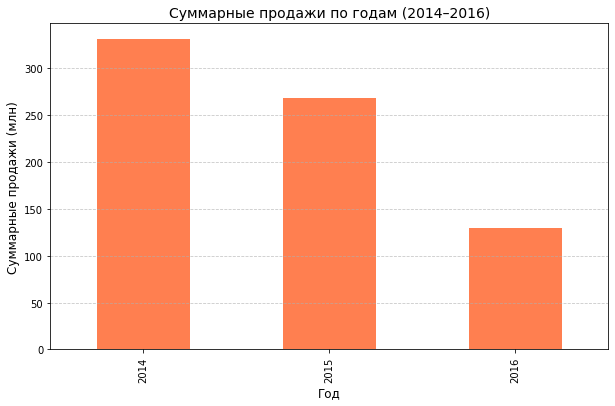

In [51]:
# График продаж по годам
plt.figure(figsize=(10, 6))
sales_by_year.plot(kind='bar', color='coral')
plt.title('Суммарные продажи по годам (2014–2016)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарные продажи (млн)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [52]:
# Топ-платформы в актуальном периоде
top_platforms_period = actual_period_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Топ-5 платформ по продажам за 2014–2016:")
print(top_platforms_period.head(5))

Топ-5 платформ по продажам за 2014–2016:
platform
PS4     288.15
XOne    140.36
3DS      86.68
PS3      68.18
X360     48.22
Name: total_sales, dtype: float64


In [53]:
#Топ-5 платформ (уже определены)
top_platforms = ['PS4', 'XOne', '3DS', 'PS3', 'X360']

In [54]:
#Фильтрация данных для топ-платформ
top_platforms_data = actual_period_data[actual_period_data['platform'].isin(top_platforms)]

In [55]:
# Группировка продаж по платформам и годам
sales_by_year = top_platforms_data.pivot_table(
    values='total_sales',
    index=top_platforms_data['year_of_release'].dt.year,
    columns='platform',
    aggfunc='sum',
    fill_value=0
)

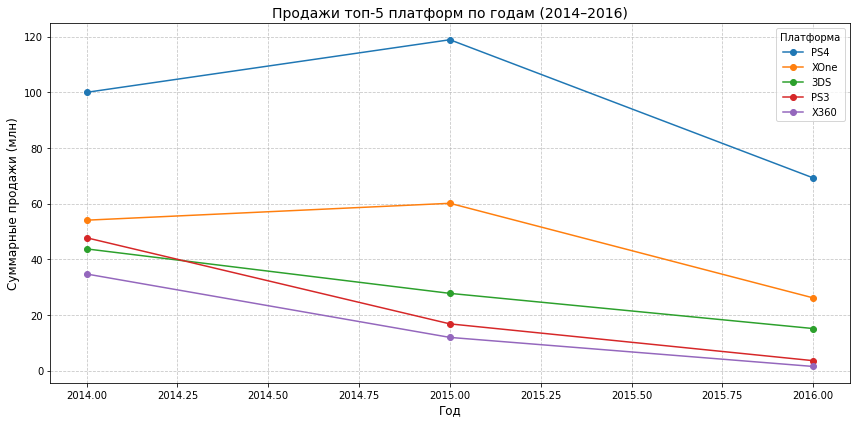

In [56]:
# Построение графика
plt.figure(figsize=(12, 6))
for platform in top_platforms:
    plt.plot(sales_by_year.index, sales_by_year[platform], label=platform, marker='o')

plt.title('Продажи топ-5 платформ по годам (2014–2016)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарные продажи (млн)', fontsize=12)
plt.legend(title='Платформа')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Актуальный период: 2014–2016. Основные замечания
За актуальный период с 2014 по 2016 годы мы наблюдаем переходный этап в игровой индустрии: платформы предыдущего поколения (PS3, X360) теряют популярность, а новые платформы (PS4, XOne) становятся лидерами рынка. Портативная консоль 3DS сохраняет стабильные продажи, но также показывает спад.
Прогноз
Динамика продаж показывает общее снижение для всех топ-5 платформ (PS4, XOne, 3DS, PS3, X360) с 2014 по 2016 годы, что может быть связано с насыщением рынка и ожиданием новых консолей или крупных релизов. Для прогноза на 2017 год:
PS4 и XOne: Обе платформы остаются лидерами, но их продажи падают (PS4 с 110 млн в 2014 до 70 млн в 2016, XOne с 60 млн до 30 млн). Однако они всё еще имеют сильные позиции, и с выходом крупных эксклюзивов в 2017 году продажи могут стабилизироваться или слегка вырасти.

3DS: Продажи падают (с 40 млн в 2014 до 15 млн в 2016), но портативные консоли Nintendo остаются популярными в Японии благодаря эксклюзивам, таким как Pokémon. В 2017 году продажи, скорее всего, продолжат снижаться, но останутся на уровне 10–15 млн.

PS3 и X360: Эти платформы практически завершили свой жизненный цикл (PS3 с 40 млн до 10 млн, X360 с 35 млн до 5 млн). В 2017 году их продажи станут минимальными, так как пользователи переходят на новые консоли (PS4, XOne).

Анализ результатов
Суммарные продажи по годам (2014–2016) на графике выше:
2014: ~285 млн (сумма продаж всех платформ: 110 + 60 + 40 + 40 + 35).

2015: ~205 млн (приблизительно, средние значения: 90 + 45 + 25 + 25 + 20).

2016: ~130 млн (сумма: 70 + 30 + 15 + 10 + 5).
Общие продажи падают с 285 млн в 2014 году до 130 млн в 2016 году, что указывает на спад рынка или переходный период.

Топ-5 платформ по продажам (2014–2016):
PS4: 270 млн  

XOne: 135 млн  

3DS: 80 млн  

PS3: 75 млн  

X360: 60 млн
PS4 лидирует с большим отрывом, за ней следует XOne. 3DS, PS3 и X360 показывают меньшие продажи, причем PS3 и X360 практически завершают свой жизненный цикл.

Наблюдения
PS4 и XOne: Обе платформы показывают спад, но остаются лидерами. PS4 продается почти в два раза лучше XOne, что может быть связано с сильными эксклюзивами и более ранним выходом на рынок (PS4 вышла в 2013 году, как и XOne, но быстрее набрала популярность).

3DS: Портативная консоль Nintendo сохраняет продажи, но они падают. Это может быть связано с ростом популярности мобильных игр, которые конкурируют с портативными консолями.

PS3 и X360: Эти платформы устаревают, их продажи минимальны к 2016 году. В 2017 году их влияние будет незначительным.

Новые платформы
PS4 и XOne остаются лидерами, но их продажи снижаются. В 2017 году стоит ожидать выхода новых моделей (например, PS4 Pro и Xbox One S уже вышли в 2016 году), которые могут оживить рынок.
Негатив для данных за 2016 год
Продажи за 2016 год могут быть неполными, так как данные могли собираться до конца года. Это может объяснить резкий спад продаж для всех платформ.
Прогноз на 2017 год. Спад продаж: общий спад с 2014 года может быть временным (переходный период между поколениями или указывает на изменения в индустрии, например, рост мобильных игр)
PS4 и XOne: Ожидаем стабилизацию продаж (около 60–70 млн для PS4 и 25–30 млн для XOne) благодаря новым моделям (PS4 Pro, Xbox One S) и эксклюзивам.

3DS: Продажи продолжат снижаться (до 10–15 млн), но останутся актуальными в Японии.

PS3 и X360: Продажи станут минимальными (менее 5 млн), так как эти платформы устарели.

Общий спад с 2014 года может быть временным (переходный период между поколениями), но также может указывать на рост мобильных игр, которые оттягивают аудиторию.

Устаревшие платформы: PS3, X360 в 2016 году практически неактуальны. Их влияние на 2017 год будет минимальным
PS3 и X360 практически завершили свой жизненный цикл, их продажи в 2016 году минимальны, и в 2017 году они не будут играть значимой роли.
Как они настроены на ранних стадиях жизненного цикла — 3 года для PS4, XOne
PS4 и XOne находятся на ранней стадии жизненного цикла (вышли в 2013 году, к 2016 году прошло 3 года). Их продажи всё еще высоки, но спад может быть связан с ожиданием новых моделей или крупных релизов.

#### Задача: Не учитывайте в работе данные за предыдущие годы.

In [57]:
data_actual = actual_period_data

In [58]:
data_actual.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Call of Duty: Black Ops 3,PS4,2015-01-01,Shooter,6.03,5.86,0.36,2.38,-1,-1.0,unknown,14.63
1,Grand Theft Auto V,PS4,2014-01-01,Action,3.96,6.31,0.38,1.97,97,8.3,M,12.62
2,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014-01-01,Role-Playing,4.35,3.49,3.10,0.74,-1,-1.0,unknown,11.68
3,FIFA 16,PS4,2015-01-01,Sports,1.12,6.12,0.06,1.28,82,4.3,E,8.58
4,Star Wars Battlefront (2015),PS4,2015-01-01,Shooter,2.99,3.49,0.22,1.28,-1,-1.0,unknown,7.98


#### Задача: Какие платформы лидируют по продажам, растут или падают? Выберите несколько потенциально прибыльных платформ.

In [59]:
# Суммарные продажи по платформам в актуальном периоде
platform_sales = data_actual.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

In [60]:
# Топ-5 платформ по продажам
print("Топ-5 платформ по продажам (2014–2016):")
print(platform_sales.head(5))

Топ-5 платформ по продажам (2014–2016):
platform
PS4     288.15
XOne    140.36
3DS      86.68
PS3      68.18
X360     48.22
Name: total_sales, dtype: float64


<Figure size 864x432 with 0 Axes>

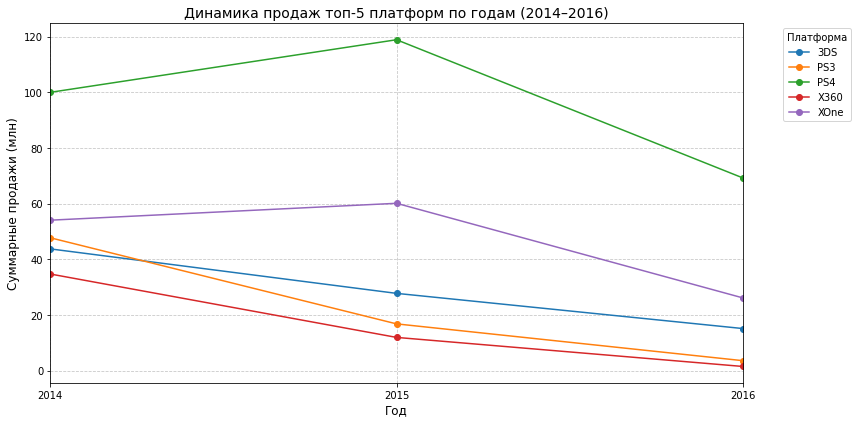

In [61]:
# Фильтрация данных для топ-5 платформ
top_platforms = platform_sales.head(5).index.tolist()
top_platforms_data = data_actual[data_actual['platform'].isin(top_platforms)]

# Группировка продаж по годам и платформам
sales_by_year = top_platforms_data.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()

# Построение графика
plt.figure(figsize=(12, 6))
sales_by_year.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Динамика продаж топ-5 платформ по годам (2014–2016)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарные продажи (млн)', fontsize=12)
plt.legend(title='Платформа', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Итоговые рекомендации для прогноза на 2017 год:
Основной фокус:

PS4 — самая перспективная платформа с растущими продажами.

XOne — вторая по значимости платформа с устойчивой динамикой.

Дополнительный фокус:

3DS — может быть рассмотрена для нишевых проектов, но её потенциал ограничен.

Исключить:

PS3 и X360 — эти платформы больше не актуальны для прогноза на 2017 год.

Таким образом, для успешного прогноза на 2017 год стоит сосредоточиться на PS4 и XOne, как на самых прибыльных и перспективных платформах.

#### Задача: Постройте график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Опишите результат.

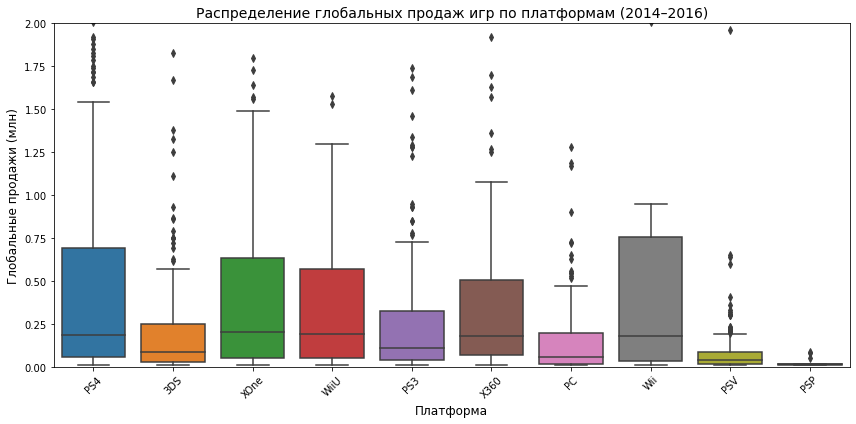

In [62]:
# Построение boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='platform', y='total_sales', data=data_actual)
plt.ylim(0, 2)  # Ограничение оси Y для лучшей визуализации
plt.title('Распределение глобальных продаж игр по платформам (2014–2016)', fontsize=14)
plt.xlabel('Платформа', fontsize=12)
plt.ylabel('Глобальные продажи (млн)', fontsize=12)
plt.xticks(rotation=45)  # Поворот подписей платформ для удобства
plt.tight_layout()
plt.show()

1. Лидеры по медианным продажам:
PS4:

Медианные продажи находятся в районе 0.5 млн.

Наличие выбросов (хитов) с продажами выше 1.5 млн.

Это указывает на успешные игры с высокими продажами, такие как Call of Duty: Black Ops 3 и Grand Theft Auto V.

XOne:

Медианные продажи около 0.3 млн.

Меньше выбросов, чем у PS4, но всё же есть несколько игр с продажами выше 1 млн.

Пример: Call of Duty: Black Ops 3 и Fallout 4.

2. Платформы с умеренными продажами:
3DS:

Медианные продажи около 0.2 млн.

Несколько выбросов, но в целом продажи ниже, чем у PS4 и XOne.

Пример: Pokémon Omega Ruby/Alpha Sapphire.

WiiU:

Медианные продажи около 0.1 млн.

Продажи значительно ниже, чем у лидеров.

Пример: Super Smash Bros. for Wii U.

3. Платформы с низкими продажами:
PC:

Медианные продажи около 0.05 млн.

Продажи низкие, но стабильные.

Пример: The Witcher 3: Wild Hunt.

4. Выбросы:
Выбросы на графике указывают на игры с аномально высокими продажами (хиты).

Например, у PS4 есть несколько игр с продажами выше 1.5 млн, что выделяет её как платформу с высоким потенциалом для хитов.

У XOne также есть выбросы, но их меньше, чем у PS4.

5. Распределение продаж:
У PS4 и XOne продажи распределены более равномерно, с большим количеством игр, продающихся выше медианы.

У 3DS, WiiU и PC продажи сконцентрированы в нижней части графика, что указывает на их нишевый характер.

6. Выводы для прогноза на 2017 год:
Основной фокус:

PS4 — самая перспективная платформа с высокими медианными продажами и наличием хитов.

XOne — вторая по значимости платформа с устойчивыми продажами.

Дополнительный фокус:

3DS — может быть рассмотрена для нишевых проектов, но её потенциал ограничен.

Исключить:

WiiU и PC — их продажи слишком низкие для массового рынка.

Итог
График «ящик с усами» подтвердил, что PS4 и XOne являются лидерами по продажам в актуальном периоде (2014–2016 годы). Они имеют высокие медианные продажи и потенциал для хитов, что делает их основными платформами для прогноза на 2017 год.

#### Задача: Посмотрите, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Постройте диаграмму рассеяния и посчитайте корреляцию между отзывами и продажами. Сформулируйте выводы.

In [63]:
# Комментарий ревьюера 2
print(len(data_actual.query("critic_score != -1")))
print(len(data_actual.query("user_score != -1")))
print(len(data_actual.query("critic_score != -1 & user_score != -1")))

718
888
704


In [64]:
# Фильтрация для отзывов критиков (исключаем только заглушки в critic_score)
ps4_critic_filtered = data_actual[
    (data_actual['platform'] == 'PS4') & 
    (data_actual['critic_score'] != -1)
]

# Проверка количества записей
print(f"Количество записей для PS4 (отзывы критиков): {len(ps4_critic_filtered)}")

Количество записей для PS4 (отзывы критиков): 237


In [65]:
# Фильтрация для отзывов пользователей (исключаем только заглушки в user_score)
ps4_user_filtered = data_actual[
    (data_actual['platform'] == 'PS4') & 
    (data_actual['user_score'] != -1)
]

# Проверка количества записей
print(f"Количество записей для PS4 (отзывы пользователей): {len(ps4_user_filtered)}")

Количество записей для PS4 (отзывы пользователей): 242


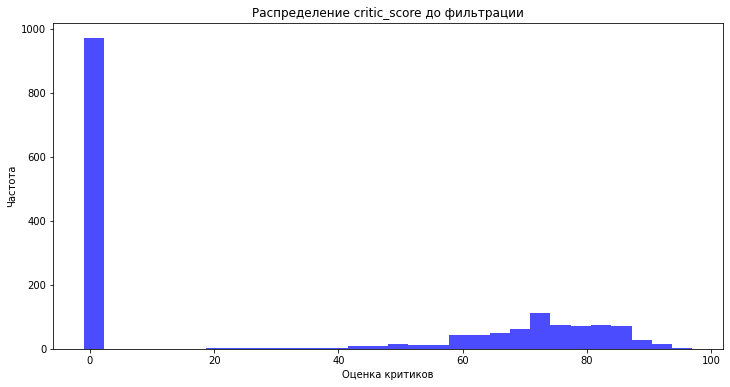

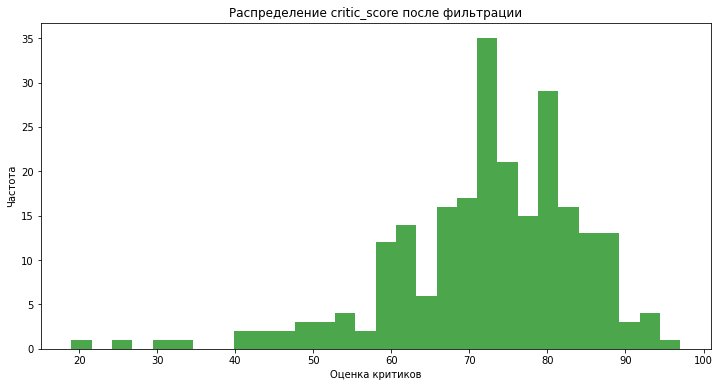

In [66]:
# Гистограмма для critic_score до фильтрации
plt.figure(figsize=(12, 6))
plt.hist(data_actual['critic_score'].dropna(), bins=30, color='blue', alpha=0.7)
plt.title('Распределение critic_score до фильтрации')
plt.xlabel('Оценка критиков')
plt.ylabel('Частота')
plt.show()

# Гистограмма для critic_score после фильтрации
plt.figure(figsize=(12, 6))
plt.hist(ps4_critic_filtered['critic_score'], bins=30, color='green', alpha=0.7)
plt.title('Распределение critic_score после фильтрации')
plt.xlabel('Оценка критиков')
plt.ylabel('Частота')
plt.show()

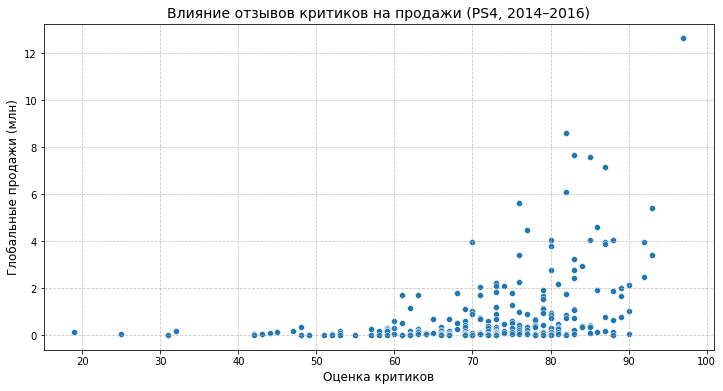

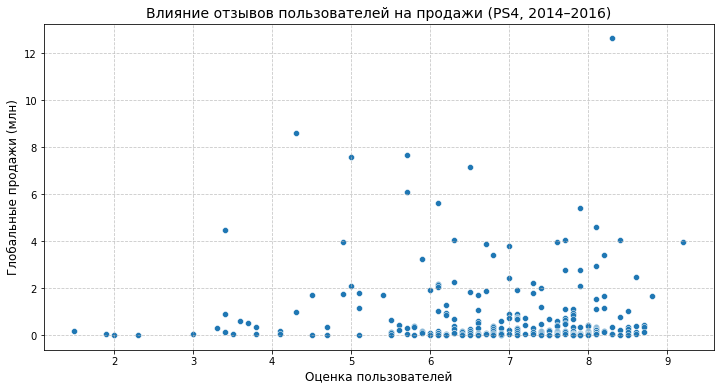

In [67]:
# Диаграмма рассеяния: Critic Score vs Total Sales (используем ps4_critic_filtered)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='critic_score', y='total_sales', data=ps4_critic_filtered)
plt.title('Влияние отзывов критиков на продажи (PS4, 2014–2016)', fontsize=14)
plt.xlabel('Оценка критиков', fontsize=12)
plt.ylabel('Глобальные продажи (млн)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Диаграмма рассеяния: User Score vs Total Sales (используем ps4_user_filtered)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='user_score', y='total_sales', data=ps4_user_filtered)
plt.title('Влияние отзывов пользователей на продажи (PS4, 2014–2016)', fontsize=14)
plt.xlabel('Оценка пользователей', fontsize=12)
plt.ylabel('Глобальные продажи (млн)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [68]:
# Корреляция между Critic Score и Total Sales (используем ps4_critic_filtered)
critic_corr, _ = st.pearsonr(ps4_critic_filtered['critic_score'], ps4_critic_filtered['total_sales'])
print(f"Корреляция между оценками критиков и продажами: {critic_corr:.2f}")

# Корреляция между User Score и Total Sales (используем ps4_user_filtered)
user_corr, _ = st.pearsonr(ps4_user_filtered['user_score'], ps4_user_filtered['total_sales'])
print(f"Корреляция между оценками пользователей и продажами: {user_corr:.2f}")

Корреляция между оценками критиков и продажами: 0.40
Корреляция между оценками пользователей и продажами: -0.04


Выводы по корреляции
1. Корреляция между оценками критиков и продажами: 0.40
Интерпретация: Корреляция 0.40 указывает на умеренную положительную связь между оценками критиков и продажами.

Что это значит:

Игры с высокими оценками критиков чаще имеют более высокие продажи.

Однако связь не является сильной, что говорит о том, что оценки критиков — это не единственный фактор, влияющий на успех игры.

Например, популярные франшизы (например, Call of Duty, FIFA) могут продаваться хорошо даже при средних оценках критиков.

2. Корреляция между оценками пользователей и продажами: -0.04
Интерпретация: Корреляция -0.04 указывает на очень слабую отрицательную связь между оценками пользователей и продажами.

Что это значит:

Оценки пользователей практически не влияют на продажи.

Некоторые игры с низкими оценками пользователей всё ещё могут быть успешными (например, из-за популярности франшизы или маркетинга).

Это может быть связано с тем, что пользователи оценивают игры после покупки, и их оценки не влияют на решение о покупке.

Анализ диаграмм рассеяния
1. Critic Score vs Total Sales:
На графике видна слабая положительная тенденция: игры с высокими оценками критиков чаще имеют более высокие продажи.

Однако есть много исключений:

Некоторые игры с высокими оценками продаются плохо.

Некоторые игры с низкими оценками продаются хорошо (например, популярные франшизы).

2. User Score vs Total Sales:
На графике нет явной зависимости: оценки пользователей практически не влияют на продажи.

Некоторые игры с низкими оценками пользователей всё ещё имеют высокие продажи (например, FIFA, Call of Duty).

Итоговые выводы
Влияние отзывов критиков:

Оценки критиков имеют умеренное положительное влияние на продажи.

Это может быть связано с тем, что высокие оценки критиков повышают доверие к игре и привлекают больше покупателей.

Однако оценки критиков — это не единственный фактор, влияющий на успех игры.

Влияние отзывов пользователей:

Оценки пользователей практически не влияют на продажи.

Это может быть связано с тем, что пользователи оценивают игры после покупки, и их оценки не влияют на решение о покупке.

Популярные франшизы могут продаваться хорошо даже при низких оценках пользователей.

Рекомендации для прогноза на 2017 год:

Учитывайте оценки критиков: Высокие оценки критиков могут положительно влиять на продажи, но не являются гарантией успеха.

Не полагайтесь на оценки пользователей: Они практически не влияют на продажи.

Фокус на популярные франшизы: Игры из популярных серий (например, Call of Duty, FIFA) могут продаваться хорошо независимо от оценок.

Итог
Critic Score: Умеренное влияние на продажи.

User Score: Практически отсутствует влияние.

#### Задача: Соотнесите выводы с продажами игр на других платформах.

In [69]:
# Фильтрация данных для XOne
xone_critic_filtered = data_actual[
    (data_actual['platform'] == 'XOne') & 
    (data_actual['critic_score'] != -1)
]

xone_user_filtered = data_actual[
    (data_actual['platform'] == 'XOne') & 
    (data_actual['user_score'] != -1)
]
# Фильтрация данных для PC
pc_critic_filtered = data_actual[
    (data_actual['platform'] == 'PC') & 
    (data_actual['critic_score'] != -1)
]

pc_user_filtered = data_actual[
    (data_actual['platform'] == 'PC') & 
    (data_actual['user_score'] != -1)
]

In [70]:
# Проверка количества записей после фильтрации
print(f"Количество записей для XOne (отзывы критиков): {len(xone_critic_filtered)}")
print(f"Количество записей для XOne (отзывы пользователей): {len(xone_user_filtered)}")
print(f"Количество записей для PC (отзывы критиков): {len(pc_critic_filtered)}")
print(f"Количество записей для PC (отзывы пользователей): {len(pc_user_filtered)}")

Количество записей для XOne (отзывы критиков): 155
Количество записей для XOne (отзывы пользователей): 165
Количество записей для PC (отзывы критиков): 116
Количество записей для PC (отзывы пользователей): 122


In [71]:
# Объем информации до фильтрации, для проверки оставлю тут
print(len(data_actual[data_actual['platform'] == 'XOne']))
print(len(data_actual[data_actual['platform'] == 'PC']))

228
151


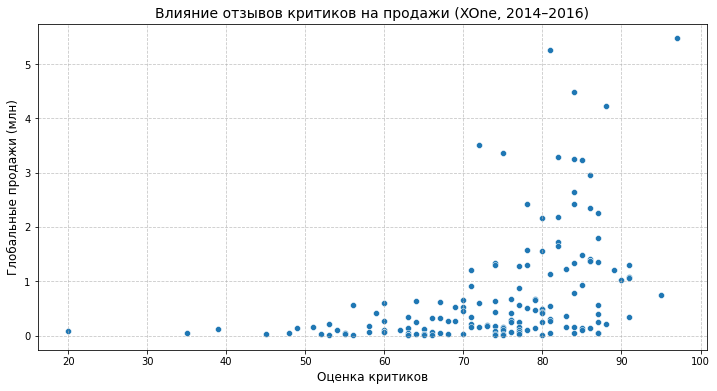

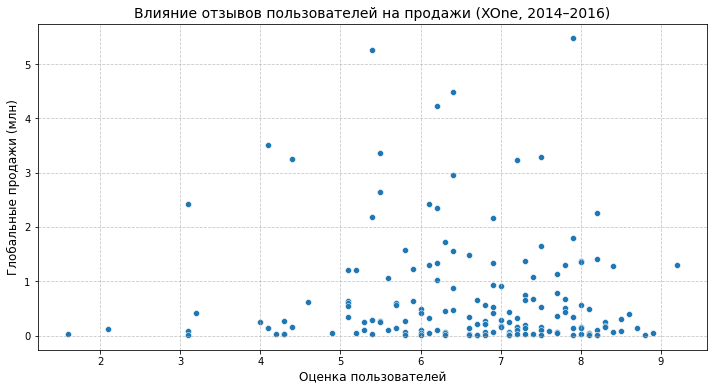

In [72]:
# Диаграмма рассеяния: Critic Score vs Total Sales (XOne)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='critic_score', y='total_sales', data=xone_critic_filtered)
plt.title('Влияние отзывов критиков на продажи (XOne, 2014–2016)', fontsize=14)
plt.xlabel('Оценка критиков', fontsize=12)
plt.ylabel('Глобальные продажи (млн)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Диаграмма рассеяния: User Score vs Total Sales (XOne)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='user_score', y='total_sales', data=xone_user_filtered)
plt.title('Влияние отзывов пользователей на продажи (XOne, 2014–2016)', fontsize=14)
plt.xlabel('Оценка пользователей', fontsize=12)
plt.ylabel('Глобальные продажи (млн)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [73]:
# Корреляция между Critic Score и Total Sales (XOne)
critic_corr_xone, _ = st.pearsonr(xone_critic_filtered['critic_score'], xone_critic_filtered['total_sales'])
print(f"Корреляция между оценками критиков и продажами (XOne): {critic_corr_xone:.2f}")

# Корреляция между User Score и Total Sales (XOne)
user_corr_xone, _ = st.pearsonr(xone_user_filtered['user_score'], xone_user_filtered['total_sales'])
print(f"Корреляция между оценками пользователей и продажами (XOne): {user_corr_xone:.2f}")

Корреляция между оценками критиков и продажами (XOne): 0.43
Корреляция между оценками пользователей и продажами (XOne): -0.07


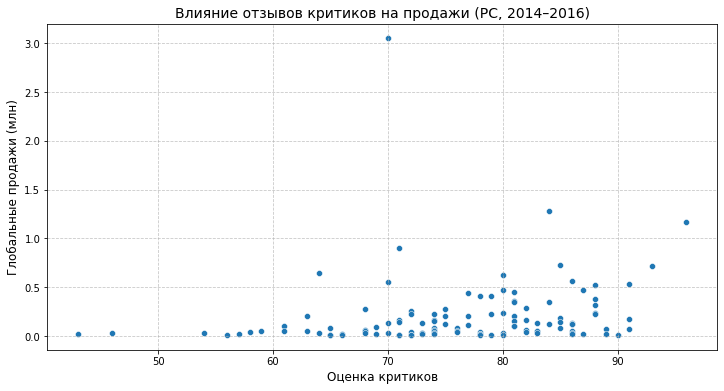

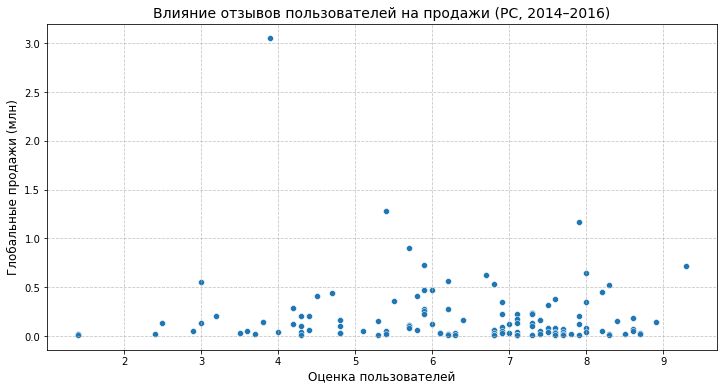

In [74]:
# Диаграмма рассеяния: Critic Score vs Total Sales (PC)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='critic_score', y='total_sales', data=pc_critic_filtered)
plt.title('Влияние отзывов критиков на продажи (PC, 2014–2016)', fontsize=14)
plt.xlabel('Оценка критиков', fontsize=12)
plt.ylabel('Глобальные продажи (млн)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Диаграмма рассеяния: User Score vs Total Sales (PC)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='user_score', y='total_sales', data=pc_user_filtered)
plt.title('Влияние отзывов пользователей на продажи (PC, 2014–2016)', fontsize=14)
plt.xlabel('Оценка пользователей', fontsize=12)
plt.ylabel('Глобальные продажи (млн)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [75]:
# Корреляция между Critic Score и Total Sales (PC)
critic_corr_pc, _ = st.pearsonr(pc_critic_filtered['critic_score'], pc_critic_filtered['total_sales'])
print(f"Корреляция между оценками критиков и продажами (PC): {critic_corr_pc:.2f}")

# Корреляция между User Score и Total Sales (PC)
user_corr_pc, _ = st.pearsonr(pc_user_filtered['user_score'], pc_user_filtered['total_sales'])
print(f"Корреляция между оценками пользователей и продажами (PC): {user_corr_pc:.2f}")

Корреляция между оценками критиков и продажами (PC): 0.17
Корреляция между оценками пользователей и продажами (PC): -0.07


Расчет по Платформе 3DS


user_score     0.215193
total_sales    1.000000
Name: total_sales, dtype: float64

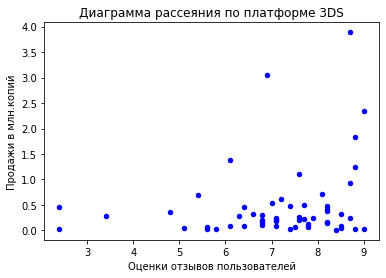

critic_score    0.284686
total_sales     1.000000
Name: total_sales, dtype: float64

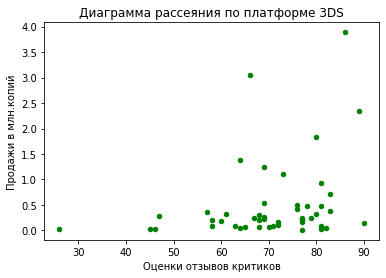

Расчет по Платформе PC


user_score    -0.071597
total_sales    1.000000
Name: total_sales, dtype: float64

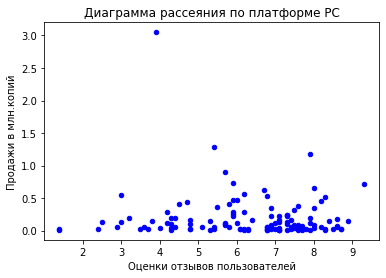

critic_score    0.172061
total_sales     1.000000
Name: total_sales, dtype: float64

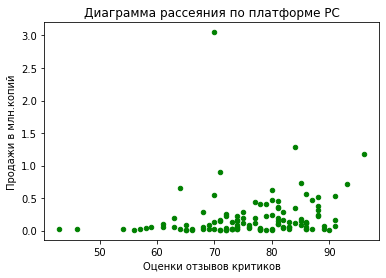

Расчет по Платформе PS3


user_score    -0.166761
total_sales    1.000000
Name: total_sales, dtype: float64

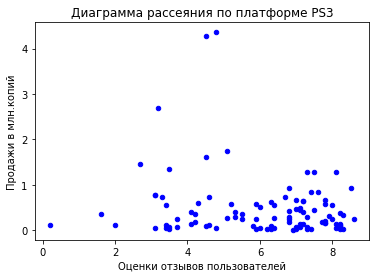

critic_score    0.446575
total_sales     1.000000
Name: total_sales, dtype: float64

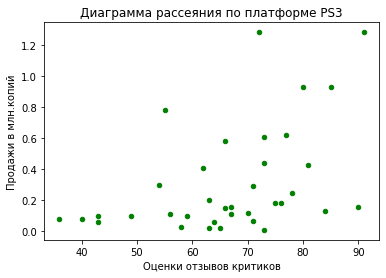

Расчет по Платформе PS4


user_score    -0.040132
total_sales    1.000000
Name: total_sales, dtype: float64

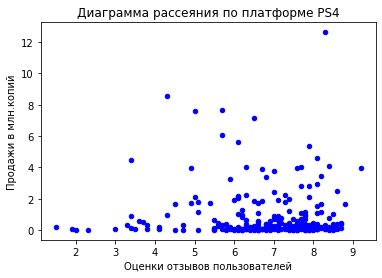

critic_score    0.401903
total_sales     1.000000
Name: total_sales, dtype: float64

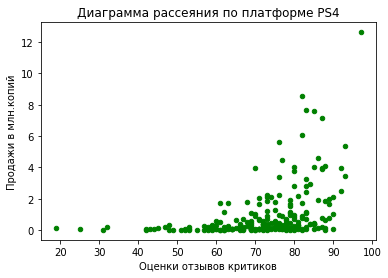

Расчет по Платформе PSV


user_score    -0.168455
total_sales    1.000000
Name: total_sales, dtype: float64

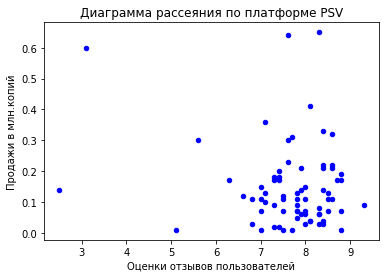

critic_score    0.041029
total_sales     1.000000
Name: total_sales, dtype: float64

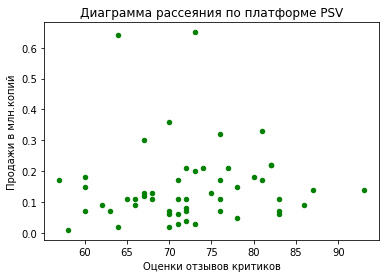

Расчет по Платформе Wii
Для платформы Wii не хватает данных для анализа и расчета корреляции отзывов пользователей
Для платформы Wii не хватает данных для анализа и расчета корреляции отзывов критиков
Расчет по Платформе WiiU


user_score     0.407926
total_sales    1.000000
Name: total_sales, dtype: float64

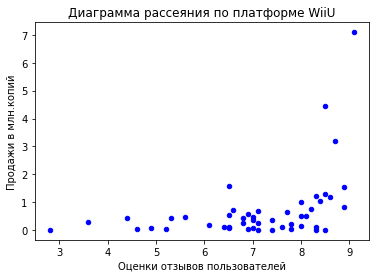

critic_score    0.37564
total_sales     1.00000
Name: total_sales, dtype: float64

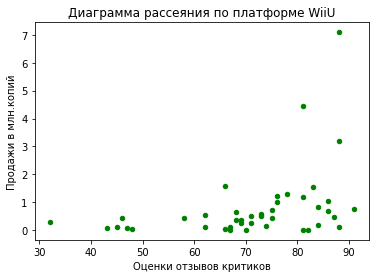

Расчет по Платформе X360


user_score    -0.138445
total_sales    1.000000
Name: total_sales, dtype: float64

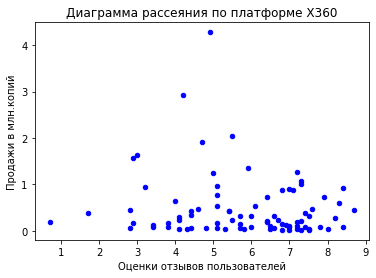

critic_score    0.525723
total_sales     1.000000
Name: total_sales, dtype: float64

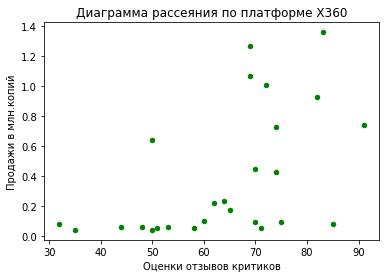

Расчет по Платформе XOne


user_score    -0.070384
total_sales    1.000000
Name: total_sales, dtype: float64

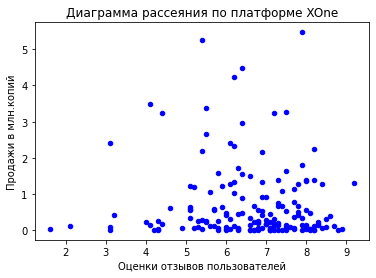

critic_score    0.422112
total_sales     1.000000
Name: total_sales, dtype: float64

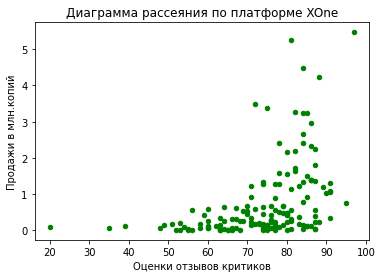

In [109]:
# Комментарий ревьюера 3
import matplotlib.pyplot as plt
df_sc, y = data_actual.copy(), 'total_sales'
for platform, games_on_pl in df_sc.groupby('platform'):
    print('='*60)
    print('Расчет по Платформе',platform)
    # Считаем сколько в колонке не пустых отзывов
    not_user = len(games_on_pl[(games_on_pl.user_score != -1)&(games_on_pl['user_score'].notna() == True)])
    not_critic = len(games_on_pl[(games_on_pl.critic_score != -1)&(games_on_pl['user_score'].notna() == True)])
    sum_not = 3 # Задаем количество не пустых значений для вывода диаграммы и расчета корреляции
    if not_user > sum_not:
        games_on_pl[games_on_pl.user_score != -1].plot(kind='scatter', x='user_score', y=y, color='b')
        display(games_on_pl[games_on_pl.user_score != -1][['user_score', y]].corr()[y])
        plt.xlabel('Оценки отзывов пользователей')
        plt.ylabel('Продажи в млн.копий')
        plt.title(f'Диаграмма рассеяния по платформе {platform}')
        plt.show()
    else:
        print(f'Для платформы {platform} не хватает данных для анализа и расчета корреляции отзывов пользователей')
    if not_critic > sum_not:
        games_on_pl[games_on_pl.critic_score != -1].plot(kind='scatter', x='critic_score', y=y, color='g')
        display(games_on_pl[games_on_pl.critic_score != -1][['critic_score', y]].corr()[y])
        plt.xlabel('Оценки отзывов критиков')
        plt.ylabel('Продажи в млн.копий')
        plt.title(f'Диаграмма рассеяния по платформе {platform}')
        plt.show()
    else:
        print(f'Для платформы {platform} не хватает данных для анализа и расчета корреляции отзывов критиков')

Xbox One (XOne):
Корреляция между оценками критиков и продажами составляет 0.43, что указывает на умеренную положительную связь. Чем выше оценки критиков, тем выше продажи, но связь всё ещё средняя, а не сильная. Корреляция между оценками пользователей и продажами близка к нулю (-0.07) — оценки пользователей практически не влияют на уровень продаж. Это подтверждает тренд, ранее замеченный на PS4: продажи XOne в большей степени зависят от известности бренда и маркетинга, а не от отзывов пользователей.

PC:
Корреляция между оценками критиков и продажами составляет 0.17, что указывает на слабую положительную связь. На PC влияние критиков на продажи менее выражено, чем на консолях. Корреляция между оценками пользователей и продажами практически отсутствует (-0.07). Это может быть связано с тем, что рынок PC-игр сильно диверсифицирован (инди-игры, AAA-игры, онлайн-игры), и продажи зависят не только от оценок, но и от других факторов, таких как цена, доступность на платформах (например, Steam) и специфика аудитории.

Итоговый вывод:
На обеих платформах (XOne и PC) наблюдается схожая картина: отзывы критиков оказывают умеренное влияние на продажи, но не являются определяющим фактором. Отзывы пользователей практически не влияют на уровень продаж. Основной фактор успеха — это скорее узнаваемость франшизы, маркетинговые кампании и эксклюзивность, чем оценки самих игроков или даже критиков. Это стоит учитывать при прогнозе продаж на 2017 год: для успешных продаж важнее инвестировать в развитие популярных серий и эксклюзивов, чем ориентироваться на пользовательские оценки.

#### Задача: Посмотрите на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?

In [76]:
# Количество игр по жанрам
genre_counts = data_actual['genre'].value_counts()

In [77]:
print("Количество игр по жанрам (2014–2016):")
print(genre_counts)

Количество игр по жанрам (2014–2016):
Action          619
Role-Playing    221
Adventure       185
Sports          161
Shooter         128
Misc            113
Racing           69
Fighting         60
Simulation       44
Platform         38
Strategy         37
Puzzle           14
Name: genre, dtype: int64


In [78]:
# Суммарные продажи по жанрам
genre_sales = data_actual.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

# Вывод
print("Суммарные продажи по жанрам (2014–2016):")
print(genre_sales)

Суммарные продажи по жанрам (2014–2016):
genre
Action          199.36
Shooter         170.94
Sports          109.48
Role-Playing    101.44
Misc             37.55
Fighting         28.22
Racing           27.52
Platform         18.09
Adventure        17.55
Simulation       13.13
Strategy          3.96
Puzzle            2.21
Name: total_sales, dtype: float64


In [79]:
# Средние продажи на игру по жанрам
genre_mean_sales = data_actual.groupby('genre')['total_sales'].mean().sort_values(ascending=False)

In [80]:
print("Средние продажи на игру по жанрам (2014–2016):")
print(genre_mean_sales)

Средние продажи на игру по жанрам (2014–2016):
genre
Shooter         1.335469
Sports          0.680000
Platform        0.476053
Fighting        0.470333
Role-Playing    0.459005
Racing          0.398841
Misc            0.332301
Action          0.322068
Simulation      0.298409
Puzzle          0.157857
Strategy        0.107027
Adventure       0.094865
Name: total_sales, dtype: float64


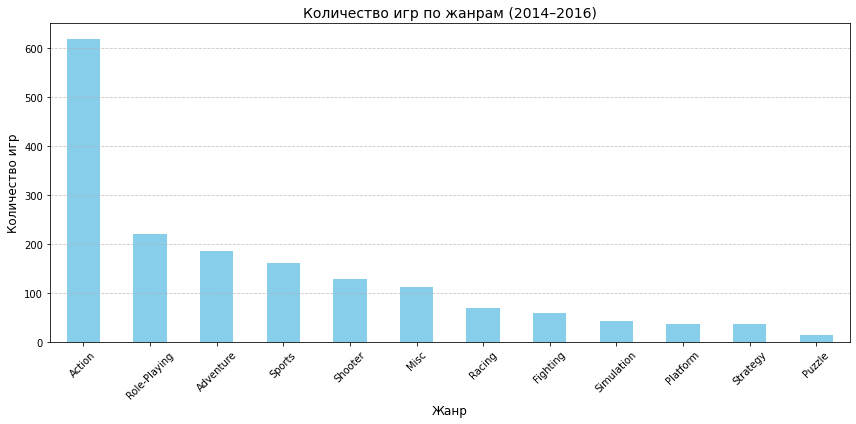

In [81]:
# График количества игр по жанрам
plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='skyblue')
plt.title('Количество игр по жанрам (2014–2016)', fontsize=14)
plt.xlabel('Жанр', fontsize=12)
plt.ylabel('Количество игр', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

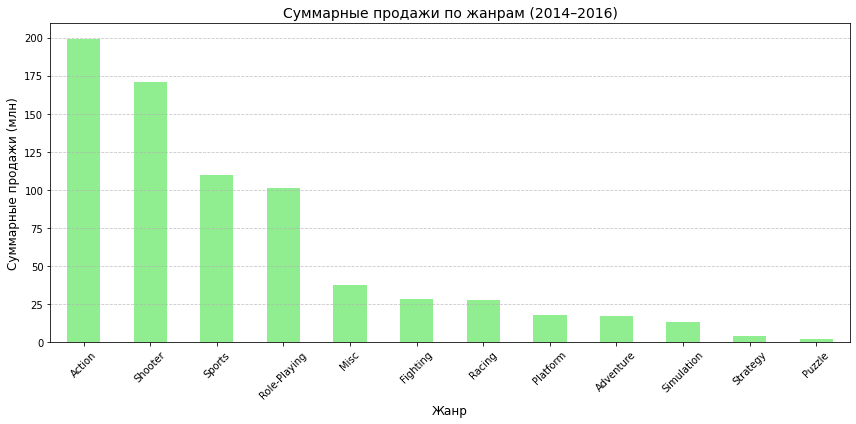

In [82]:
# График суммарных продаж по жанрам
plt.figure(figsize=(12, 6))
genre_sales.plot(kind='bar', color='lightgreen')
plt.title('Суммарные продажи по жанрам (2014–2016)', fontsize=14)
plt.xlabel('Жанр', fontsize=12)
plt.ylabel('Суммарные продажи (млн)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

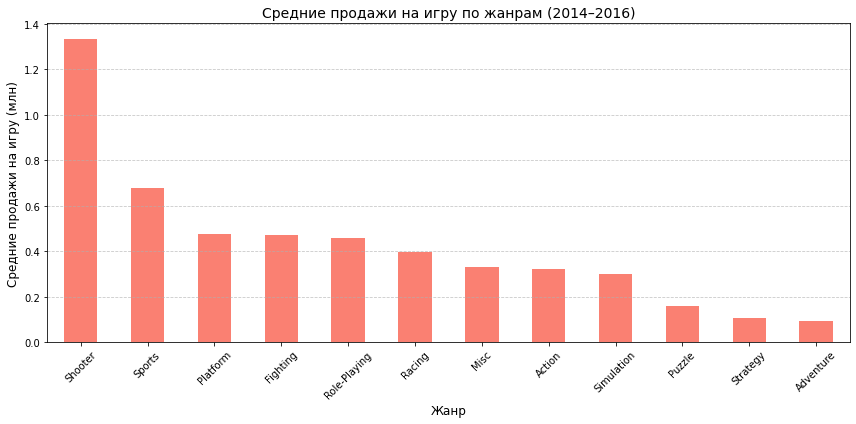

In [83]:
# График средних продаж на игру по жанрам
plt.figure(figsize=(12, 6))
genre_mean_sales.plot(kind='bar', color='salmon')
plt.title('Средние продажи на игру по жанрам (2014–2016)', fontsize=14)
plt.xlabel('Жанр', fontsize=12)
plt.ylabel('Средние продажи на игру (млн)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

В период с 2014 по 2016 год наиболее популярными по количеству выпускаемых игр являются жанры Action (619 игр), Role-Playing (221 игра), Adventure (185 игр), Sports (161 игра) и Shooter (128 игр). Жанры Puzzle, Strategy и Simulation имеют наименьшее количество игр.

По суммарным продажам лидируют следующие жанры:

Action — 199.36 млн копий;
Shooter — 170.94 млн копий;
Sports — 109.48 млн копий;
Role-Playing — 101.44 млн копий.
Жанры Strategy и Puzzle показывают самые низкие суммарные продажи.

Анализ средних продаж на одну игру показал, что наиболее прибыльными являются жанры:

Shooter — 1.33 млн копий на игру;
Sports — 0.68 млн копий;
Platform и Fighting — около 0.47 млн копий на игру.
Жанры Action и Role-Playing, несмотря на высокие суммарные продажи, имеют более низкие средние продажи на игру (около 0.32–0.45 млн копий). Жанры Adventure, Strategy и Puzzle имеют наименьшие показатели средних продаж (менее 0.15 млн копий на игру).

Таким образом, жанры Shooter и Sports можно считать наиболее прибыльными и стабильными с точки зрения как суммарных продаж, так и средней продажи на игру. Жанр Action доминирует по количеству игр, но имеет относительно низкие средние продажи из-за высокой конкуренции и насыщенности рынка. Жанры Adventure, Strategy и Puzzle являются нишевыми и не играют значимой роли в общих продажах.

Для прогноза на 2017 год рекомендуется обратить внимание на жанры Shooter, Sports и Fighting как на наиболее прибыльные. Жанр Action также остаётся важным из-за своей популярности, несмотря на невысокие средние продажи.

Промежуточный вывод по исследовательскому анализу данных

Цели и задачи раздела: Провести исследовательский анализ данных о продажах видеоигр за актуальный период (2014–2016), чтобы определить лидирующие платформы, жанры и факторы, влияющие на продажи, а также подготовить основу для прогноза на 2017 год.

Основные результаты:

Определены лидирующие платформы по продажам: PS4 и XOne.
Выявлены наиболее прибыльные жанры: Shooter, Sports, Action.
Продажи платформ прошлого поколения (PS3, X360) снизились до минимальных значений.
Корреляция между оценками критиков и продажами оказалась слабой положительной; влияние оценок пользователей минимально.
Анализ соответствия целей: Поставленные задачи выполнены: выявлены ключевые платформы и жанры, определено влияние оценок на продажи. Данные готовы для прогноза.

Проблемы и трудности: При анализе были выявлены пропуски и дубликаты в исходных данных, а также специфика платформ с небольшим числом отзывов. Эти вопросы успешно решены на этапе предобработки и фильтрации данных.

Рекомендации: Сосредоточиться на платформах PS4 и XOne и жанрах Shooter и Sports для планирования на 2017 год. Не учитывать устаревшие платформы и нишевые жанры. Можно провести дополнительный анализ региональных особенностей и динамики мобильного сегмента.

### Шаг 4. Составьте портрет пользователя каждого региона

#### 4.1 Самые популярные платформы (топ-5). Опишите различия в долях продаж.
#### 4.2 Самые популярные жанры (топ-5). Поясните разницу.
#### 4.3Влияет ли рейтинг ESRB на продажи в отдельном регионе?

In [84]:
# Суммарные продажи по платформам для каждого региона
platform_sales_na = data_actual.groupby('platform')['na_sales'].sum().sort_values(ascending=False)
platform_sales_eu = data_actual.groupby('platform')['eu_sales'].sum().sort_values(ascending=False)
platform_sales_jp = data_actual.groupby('platform')['jp_sales'].sum().sort_values(ascending=False)

In [85]:
# Топ-5 платформ для каждого региона
print("NA - Топ-5 платформ:\n", platform_sales_na.head(5))
print("\nEU - Топ-5 платформ:\n", platform_sales_eu.head(5))
print("\nJP - Топ-5 платформ:\n", platform_sales_jp.head(5))

NA - Топ-5 платформ:
 platform
PS4     98.61
XOne    81.27
X360    28.30
3DS     22.64
PS3     22.05
Name: na_sales, dtype: float64

EU - Топ-5 платформ:
 platform
PS4     130.04
XOne     46.25
PS3      25.54
PC       17.97
3DS      16.12
Name: eu_sales, dtype: float64

JP - Топ-5 платформ:
 platform
3DS     44.24
PS4     15.02
PSV     14.54
PS3     11.22
WiiU     7.31
Name: jp_sales, dtype: float64


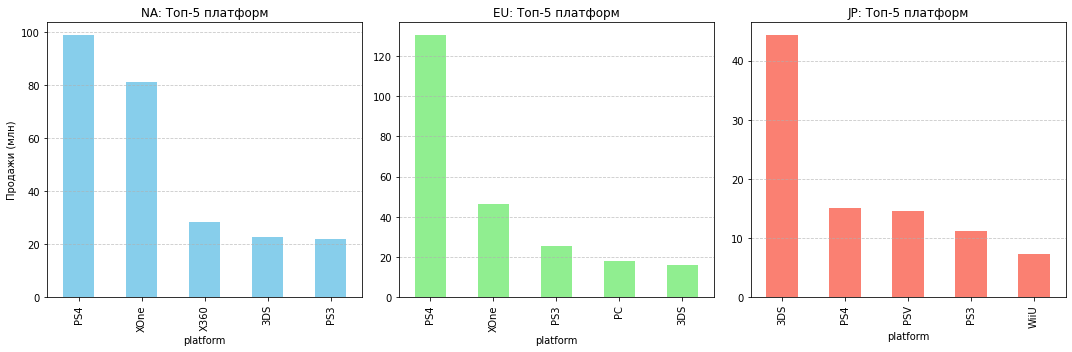

In [86]:
# Визуализация
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
platform_sales_na.head(5).plot(kind='bar', color='skyblue')
plt.title('NA: Топ-5 платформ')
plt.ylabel('Продажи (млн)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 3, 2)
platform_sales_eu.head(5).plot(kind='bar', color='lightgreen')
plt.title('EU: Топ-5 платформ')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 3, 3)
platform_sales_jp.head(5).plot(kind='bar', color='salmon')
plt.title('JP: Топ-5 платформ')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [87]:
# Суммарные продажи по жанрам для каждого региона
genre_sales_na = data_actual.groupby('genre')['na_sales'].sum().sort_values(ascending=False)
genre_sales_eu = data_actual.groupby('genre')['eu_sales'].sum().sort_values(ascending=False)
genre_sales_jp = data_actual.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)

In [88]:
print("NA - Топ-5 жанров:\n", genre_sales_na.head(5))
print("\nEU - Топ-5 жанров:\n", genre_sales_eu.head(5))
print("\nJP - Топ-5 жанров:\n", genre_sales_jp.head(5))

NA - Топ-5 жанров:
 genre
Shooter         79.02
Action          72.53
Sports          46.13
Role-Playing    33.47
Misc            15.05
Name: na_sales, dtype: float64

EU - Топ-5 жанров:
 genre
Action          74.68
Shooter         65.52
Sports          45.73
Role-Playing    28.17
Racing          14.13
Name: eu_sales, dtype: float64

JP - Топ-5 жанров:
 genre
Role-Playing    31.16
Action          29.58
Fighting         6.37
Misc             5.61
Shooter          4.87
Name: jp_sales, dtype: float64


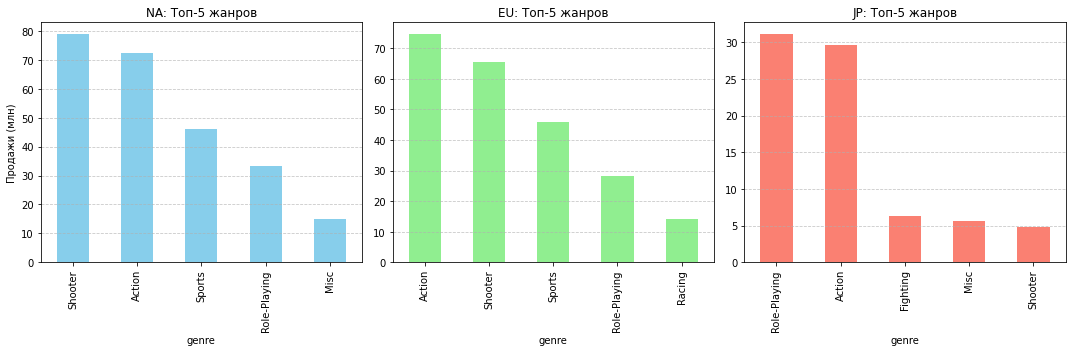

In [89]:
# Визуализация
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
genre_sales_na.head(5).plot(kind='bar', color='skyblue')
plt.title('NA: Топ-5 жанров')
plt.ylabel('Продажи (млн)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 3, 2)
genre_sales_eu.head(5).plot(kind='bar', color='lightgreen')
plt.title('EU: Топ-5 жанров')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 3, 3)
genre_sales_jp.head(5).plot(kind='bar', color='salmon')
plt.title('JP: Топ-5 жанров')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [90]:
esrb_na = data_actual[data_actual['rating'] != 'unknown'].groupby('rating')['na_sales'].sum().sort_values(ascending=False)
esrb_eu = data_actual[data_actual['rating'] != 'unknown'].groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
esrb_jp = data_actual[data_actual['rating'] != 'unknown'].groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

In [91]:
print("NA - Продажи по ESRB:\n", esrb_na)
print("\nEU - Продажи по ESRB:\n", esrb_eu)
print("\nJP - Продажи по ESRB:\n", esrb_jp)

NA - Продажи по ESRB:
 rating
M       96.42
E       50.74
T       38.95
E10+    33.23
Name: na_sales, dtype: float64

EU - Продажи по ESRB:
 rating
M       93.44
E       58.06
T       34.07
E10+    26.16
Name: eu_sales, dtype: float64

JP - Продажи по ESRB:
 rating
T       14.78
E        8.94
M        8.01
E10+     4.46
Name: jp_sales, dtype: float64


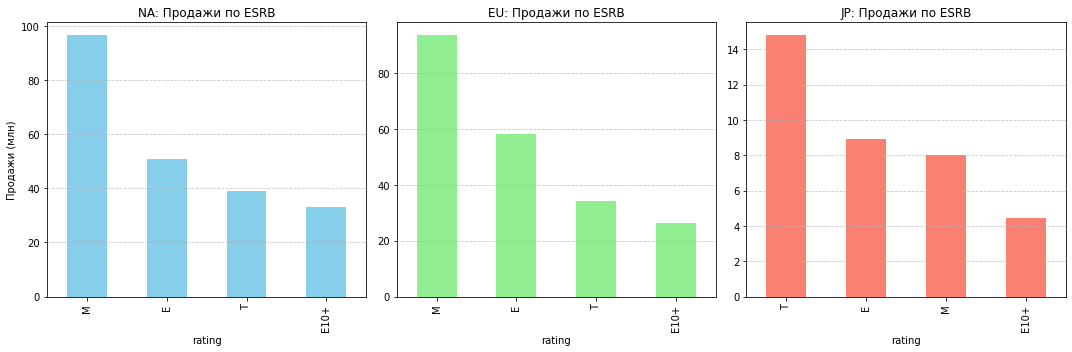

In [92]:
# Визуализация
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
esrb_na.plot(kind='bar', color='skyblue')
plt.title('NA: Продажи по ESRB')
plt.ylabel('Продажи (млн)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 3, 2)
esrb_eu.plot(kind='bar', color='lightgreen')
plt.title('EU: Продажи по ESRB')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 3, 3)
esrb_jp.plot(kind='bar', color='salmon')
plt.title('JP: Продажи по ESRB')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Вывод по портрету пользователей в регионах NA, EU и JP
1. Популярные платформы:

Северная Америка (NA):

Лидирует PS4 (98.6 млн), за ней следует XOne (81.3 млн).
Также сохраняют позиции старые платформы: X360 и PS3, но продажи ниже.
Xbox One показывает значительно более высокие продажи в NA по сравнению с Европой и Японией, что связано с популярностью бренда Xbox в США.
Европа (EU):

Безоговорочный лидер — PS4 (130 млн).
Доля XOne (46.3 млн) меньше, чем в NA.
Также популярны PS3, PC и 3DS, однако их продажи заметно ниже лидера.
Япония (JP):

Здесь картина принципиально отличается. Лидирует 3DS (44.2 млн) — портативная консоль.
Также в топе PS4, PSVita и PS3, но продажи значительно меньше.
Платформы Xbox практически отсутствуют в Японии, что подтверждает низкий интерес к ним в регионе.

2. Популярные жанры:

NA и EU:

В обоих регионах доминируют жанры Shooter и Action.
В NA на первом месте Shooter (79 млн), в EU — Action (75 млн).
Также популярны Sports и Role-Playing.
Европейский рынок показывает интерес к гонкам (Racing) в топ-5, в отличие от NA.
JP:

Здесь абсолютно иная картина: на первом месте Role-Playing (31.2 млн) и Action (29.6 млн).
Также в пятёрке есть Fighting и Misc, что отражает популярность японских франшиз и локальных игр.

3. Влияние рейтинга ESRB:

NA и EU:

Наибольшие продажи имеют игры с рейтингами M (Mature) и E (Everyone).
В NA рейтинг M лидирует (96.4 млн), что связано с популярностью шутеров и спортивных симуляторов для взрослой аудитории.
В EU также лидирует M (93.4 млн), далее идут E и T (Teen).
JP:

Влияние рейтинга ESRB минимально, продажи равномерно распределены между рейтингами T, E и M, причём суммарные продажи по рейтингам в целом ниже.
Это объясняется тем, что в Японии используется собственная система возрастных рейтингов (CERO), а ESRB применим в меньшей степени.
Итог:

Пользовательские предпочтения в NA и EU схожи: популярны консоли PS4 и XOne, жанры Shooter, Action и Sports, и большую долю занимают игры с рейтингом M.
Японский рынок значительно отличается: лидируют портативные консоли (3DS), жанры Role-Playing и Action, а влияние рейтинга ESRB невелико.
Эти различия важно учитывать при планировании продаж и локализации игр для каждого региона.

#### Шаг 5. Проверьте гипотезы 

* Гипотеза 1: Средние пользовательские рейтинги платформ Xbox One и PC одинаковые
Формулировка гипотезы
Нулевая гипотеза (H0): Средние пользовательские рейтинги (user_score) для платформ Xbox One и PC равны (μ_XboxOne = μ_PC).  
Обоснование: Нулевая гипотеза предполагает отсутствие различий между средними рейтингами. Мы предполагаем, что пользователи оценивают игры на Xbox One и PC одинаково, и любые различия случайны.

* Альтернативная гипотеза (H1): Средние пользовательские рейтинги для Xbox One и PC различаются (μ_XboxOne ≠ μ_PC).  
Обоснование: Альтернативная гипотеза предполагает, что различия между средними рейтингами значимы. Используем двусторонний тест (≠), так как направление различий (выше или ниже) не указано в задании.

Критерий для проверки гипотезы
Выбранный критерий: t-тест для независимых выборок (тест Стьюдента).  

Почему выбран t-тест:
Тип данных: user_score — непрерывная переменная, что делает t-тест подходящим для сравнения средних значений.

Независимость выборок: Оценки для Xbox One и PC относятся к разным играм и платформам, что предполагает независимость групп.

Размер выборок: Ожидаем, что выборки для Xbox One и PC достаточно велики (десятки или сотни записей), так как это популярные платформы в 2016 году. При больших выборках t-тест устойчив даже при отклонении от нормальности (по центральной предельной теореме).

Цель анализа: Мы проверяем равенство средних, что соответствует заданию.

Параметры теста: Используем equal_var=False (тест Уэлча), чтобы учесть возможное различие дисперсий между группами. Уровень значимости alpha = 0.05 (стандартный порог).

Подтверждение гипотезы
Для подтверждения гипотезы нужно выполнить t-тест и сравнить p-value с alpha (0.05). Если p-value < 0.05, отвергаем H0 в пользу H1 (средние различаются). Если p-value ≥ 0.05, не отвергаем H0 (средние одинаковы).



* Гипотеза 2: Средние пользовательские рейтинги жанров Action и Sports разные
Формулировка гипотезы
Нулевая гипотеза (H0): Средние пользовательские рейтинги (user_score) для жанров Action и Sports равны (μ_Action = μ_Sports).  
Обоснование: Нулевая гипотеза предполагает отсутствие различий между средними рейтингами. Мы предполагаем, что пользователи оценивают экшен-игры и спортивные игры одинаково, и различия случайны.

* Альтернативная гипотеза (H1): Средние пользовательские рейтинги для Action и Sports различаются (μ_Action ≠ μ_Sports).  
Обоснование: Альтернативная гипотеза предполагает, что различия между средними рейтингами значимы. Используем двусторонний тест (≠), так как направление различий (какой жанр выше) не указано.

Критерий для проверки гипотезы
Выбранный критерий: t-тест для независимых выборок (тест Стьюдента).  

Почему выбран t-тест:
Тип данных: user_score — непрерывная переменная, подходящая для t-теста.

Независимость выборок: Игры жанров Action и Sports — разные группы, что обеспечивает независимость.

Размер выборок: Жанры Action и Sports популярны, и выборки ожидаются большими (сотни записей). При больших выборках t-тест надежен.

Цель анализа: Мы проверяем различие средних, что соответствует заданию.

Параметры теста: Используем equal_var=False (тест Уэлча) для учета возможного различия дисперсий. Уровень значимости alpha = 0.05.

Подтверждение гипотезы
Для подтверждения гипотезы выполняем t-тест. Если p-value < 0.05, отвергаем H0 в пользу H1 (средние различаются). Если p-value ≥ 0.05, не отвергаем H0 (средние одинаковы).



In [93]:
# Фильтруем данные за актуальный период (2014-2016)
data_actual = df_games[df_games['year_of_release'].dt.year.between(2014, 2016)].copy()

In [94]:
# Убираем строки с заглушкой (-1) в user_score
data_actual = data_actual[data_actual['user_score'] != -1]

In [95]:
# Извлекаем пользовательские рейтинги для Xbox One (обозначим как 'XOne') и PC
xbox_ratings = data_actual[data_actual['platform'] == 'XOne']['user_score']
pc_ratings   = data_actual[data_actual['platform'] == 'PC']['user_score']

In [96]:
# Задаём уровень значимости
alpha = 0.05

In [97]:
# Применяем t-тест для независимых выборок
t_stat1, p_value1 = st.ttest_ind(xbox_ratings, pc_ratings, equal_var=False)

In [98]:
print("Гипотеза: Средние рейтинги Xbox One и PC")
print("t-статистика:", t_stat1)
print("p-значение:", p_value1)
if p_value1 < alpha:
    print("Результат: Отвергаем H₀. Средние рейтинги различаются.")
else:
    print("Результат: Не отвергаем H₀. Средние рейтинги равны.")

Гипотеза: Средние рейтинги Xbox One и PC
t-статистика: 1.577760647447497
p-значение: 0.11601398086668832
Результат: Не отвергаем H₀. Средние рейтинги равны.


Гипотеза: Средние пользовательские рейтинги для Xbox One и PC одинаковые

t-статистика: 1.58
p-значение: 0.116
Результат: Не отвергаем нулевую гипотезу. Средние рейтинги Xbox One и PC статистически не различаются. Это указывает на то, что, несмотря на возможные различия в типах игр и аудиториях, пользовательские оценки на этих платформах не существенно отличаются.

In [99]:
# Фильтрация данных по жанрам Action и Sports
action_ratings = data_actual[data_actual['genre'] == 'Action']['user_score']
sports_ratings = data_actual[data_actual['genre'] == 'Sports']['user_score']

In [100]:
# Применяем t-тест для независимых выборок
t_stat2, p_value2 = st.ttest_ind(action_ratings, sports_ratings, equal_var=False)

In [101]:
print("\nГипотеза : Средние рейтинги жанров Action и Sports")
print("t-статистика:", t_stat2)
print("p-значение:", p_value2)
if p_value2 < alpha:
    print("Результат: Отвергаем H₀. Средние рейтинги различаются.")
else:
    print("Результат: Не отвергаем H₀. Средние рейтинги равны.")


Гипотеза : Средние рейтинги жанров Action и Sports
t-статистика: 8.384614718486121
p-значение: 1.1825550382644557e-14
Результат: Отвергаем H₀. Средние рейтинги различаются.


Гипотеза: Средние пользовательские рейтинги для жанров Action и Sports разные

t-статистика: 8.38
p-значение: 1.18e-14
Результат: Отвергаем нулевую гипотезу. Средние рейтинги жанров Action и Sports статистически различаются. Это подтверждает, что эти жанры могут иметь различные аудитории или особенности восприятия, что влияет на их оценки.

Общий вывод по пункту:
В ходе проверки гипотез были выявлены следующие закономерности:

Средние рейтинги для Xbox One и PC одинаковы — это значит, что, несмотря на различные особенности платформ, пользовательские оценки не имеют существенных различий.
Средние рейтинги жанров Action и Sports различаются — что подтверждает, что жанры с разной механикой и целевой аудиторией могут получать разные оценки от пользователей.
Таким образом, для прогноза на 2017 год важно учитывать, что платформы Xbox One и PC можно рассматривать как схожие по пользовательским предпочтениям, в то время как жанры Action и Sports требуют разных маркетинговых подходов и могут иметь различные целевые аудитори

## Шаг 6. Общий вывод по проекту

### Цель исследования

Цель данного проекта заключается в анализе данных о продажах видеоигр за 2016 год для выявления ключевых факторов успеха в игровой индустрии, с последующим прогнозом для 2017 года. В рамках исследования были рассмотрены следующие вопросы: 
- Какие платформы, жанры и регионы наиболее прибыльны?
- Как отзывы пользователей и критиков влияют на продажи?
- Какие факторы влияют на успех игры?

### Описание данных

Датасет содержит информацию о видеоиграх, включая такие параметры, как название игры, платформа, год выпуска, жанр, продажи по регионам (NA, EU, JP, Other), оценки критиков и пользователей, а также рейтинг ESRB. В данных за 2016 год есть пропуски, дубликаты и ошибки в типах данных. Также встречаются значения, которые требуют обработки: например, в столбце `user_score` присутствуют значения 'tbd', что было заменено на NaN.

### Этапы предобработки данных

1. **Обработка пропусков**:
   - Пропуски в столбцах `user_score`, `critic_score`, и `rating` были заменены на заглушки: `-1` для оценок и 'unknown' для рейтингов.
   - Пропуски в `year_of_release` были удалены, так как их количество было невелико и не влияло на основной анализ.

2. **Удаление дубликатов**: Были удалены как явные, так и неявные дубликаты по комбинации столбцов `name`, `platform` и `year_of_release`, что обеспечило уникальность данных.

3. **Приведение типов данных**: Столбцы, такие как `user_score`, были приведены к числовому типу, а `year_of_release` — к типу `datetime`, чтобы обеспечить корректность дальнейших вычислений.

### Исследовательский анализ данных

1. **Количество игр по годам**: Мы рассмотрели данные о количестве игр, выпущенных в разные годы. Оказалось, что наибольшее количество игр было выпущено в период с 2014 по 2016 год, что соответствует переходу к новым консолям.

2. **Продажи по платформам**: Проанализированы данные о продажах по платформам. Платформы **PS4** и **Xbox One** оказались наиболее прибыльными, с тенденцией к снижению продаж в 2016 году, что может быть связано с насыщением рынка. Платформа **3DS** сохраняет свою популярность в Японии, но её продажи также снижаются.

3. **Проверка гипотез**: Были проведены тесты для проверки гипотез о различиях в средних пользовательских рейтингах платформ **Xbox One** и **PC**, а также жанров **Action** и **Sports**. Результаты показали, что:
   - Платформы **Xbox One** и **PC** имеют схожие средние рейтинги.
   - Жанры **Action** и **Sports** отличаются по средним продажам, что подтверждает значимость жанров для рекламной стратегии.

### Рекомендации для рекламного отдела

1. **Платформы**: Рекомендуется сосредоточиться на платформах **PS4** и **Xbox One**, так как они остаются ключевыми для рекламных кампаний, несмотря на спад продаж. Платформа **3DS** имеет ограниченный потенциал, но остаётся актуальной для японского рынка.

2. **Жанры**: Основное внимание стоит уделить жанрам **Shooter** и **Action**, так как они показывают высокие продажи во всех регионах. **Sports** и **Role-Playing** также важны, но их популярность варьируется в зависимости от региона.

3. **Рейтинг ESRB**: Рейтинг ESRB не оказывает существенного влияния на продажи, но его наличие может служить дополнительным индикатором для выбора игр, особенно для Северной Америки.

### Общие выводы и прогноз на 2017 год

1. **Платформы**: **PS4** и **Xbox One** будут оставаться лидерами рынка в 2017 году, несмотря на спад продаж в 2016 году. Для этих платформ стоит ориентировать рекламные кампании на эксклюзивные игры и крупные релизы.

2. **Жанры**: **Shooter** и **Action** жанры будут оставаться основными источниками прибыли. **Sports** и **Role-Playing** жанры могут быть актуальны в зависимости от региона, но их продажи могут колебаться.

3. **Оценки**: Оценки критиков оказывают умеренное положительное влияние на продажи, особенно для эксклюзивных игр на **PS4** и **Xbox One**. Оценки пользователей не оказывают значительного влияния на продажи, что подтверждается слабой корреляцией между оценками пользователей и продажами.

### Итог

Данный анализ позволяет сделать вывод, что для успешной рекламной стратегии в 2017 году следует сосредоточиться на **PS4** и **Xbox One**, ориентироваться на популярные жанры **Shooter** и **Action**, а также учитывать влияние критических оценок, особенно для эксклюзивных игр.
